In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

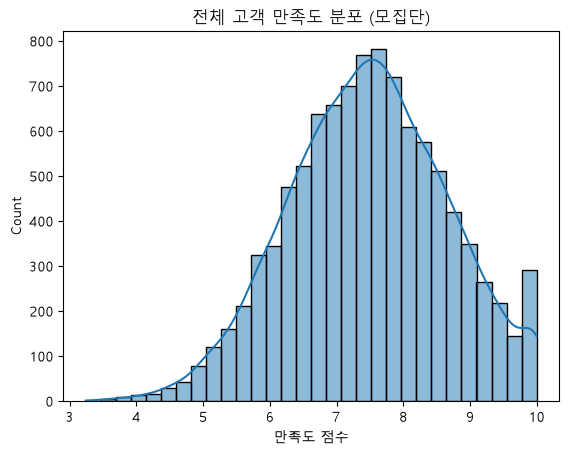

In [4]:
np.random.seed(2025)
population = np.random.normal(loc=7.5, scale=1.2, size=10000)
population = np.clip(population, 1, 10)  # 1점 ~ 10점 사이로 제한
df_pop = pd.DataFrame({'score': population})

# 전체 모집단 시각화
sns.histplot(df_pop['score'], bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

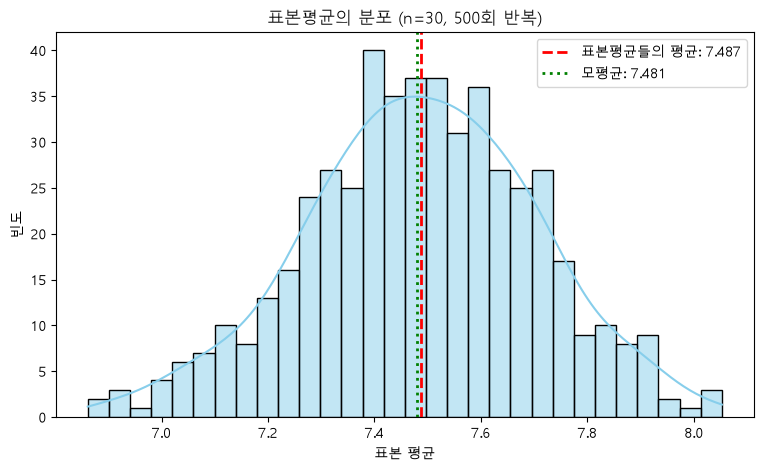

모집단 평균: 7.4806, 표준편차: 1.1814
표본평균 평균: 7.4869, 표준편차(표준오차): 0.2166
이론적 표준오차: 0.2157


In [5]:
np.random.seed(42)  # 표본추출 재현성

sample_size = 30
n_trials = 500
sample_means = []

for _ in range(n_trials):
    sample = np.random.choice(df_pop['score'], size=sample_size, replace=False)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

# 시각화
plt.figure(figsize=(9, 5))
sns.histplot(sample_means, bins=30, kde=True, color='skyblue')

plt.axvline(sample_means.mean(), color='red', linestyle='--', linewidth=2,
            label=f'표본평균들의 평균: {sample_means.mean():.3f}')
plt.axvline(df_pop['score'].mean(), color='green', linestyle=':', linewidth=2,
            label=f'모평균: {df_pop["score"].mean():.3f}')

plt.title(f"표본평균의 분포 (n={sample_size}, {n_trials}회 반복)")
plt.xlabel("표본 평균")
plt.ylabel("빈도")
plt.legend()
plt.show()

print(f"모집단 평균: {df_pop['score'].mean():.4f}, 표준편차: {df_pop['score'].std():.4f}")
print(f"표본평균 평균: {sample_means.mean():.4f}, 표준편차(표준오차): {sample_means.std():.4f}")
print(f"이론적 표준오차: {df_pop['score'].std() / np.sqrt(sample_size):.4f}")

### 표본 평균들은 어떤 값 주변에 많이 분포해 있나요? 이 값은 전체 모집단 평균과 얼마나 비슷한가요?
  - 7.49 근처에 몰려있음. 모평균과 표본평균은 0.006차이난다. 이 모평균의 불편추정량이기 때문, 개별 표본은 위 아래로 튀지만 그 오차들이 서로 상쇄되서 평균을 내면 참값에 수렴함
### 표본을 1번 뽑았을 때와 500번을 반복해서 뽑았을 때, 표본 평균의 분포나 신뢰성에는 어떤 차이가 있나요
  - 표본 평균 분포를 보면 6점대부터 8점대까지 다양하게 분포되어있다. 만약 표본을 한번만 뽑고 끝냈다면 그건 모집단의 성질을 포함한다고 할 수 없다. 하지만 500번을 반복해서 뽑았을때는
  표준편차가 0.2166이라는걸 알 수 있기 때문에 한번 뽑으면 대략 0.2정도의 오차가 날 수 있다는걸 짐작할 수 있다. 실제로 500개 중 65%가 모평균 +-0.2% 안에 들어있다.
  반복해서 뽑았을때 이 결과를 얼마나 믿어야 하는지 알려주는 방법이다.
### 친구가 다른 표본을 뽑았다면 같은 평균이 나왔을까요? 비슷한 결과가 나왔더라도 완전히 같지 않았다면, 그 이유는 무엇일까요?
  - 같은 결과가 나올 확률은 0에 수렴한다. "표본오차" 때문, 하지만 이것이 실수나 편향이 아니고 누가 뽑혔느냐에 따른 필연적인 오차이다.
### 표본 평균들의 분포는 어떤 모양인가요? 종 모양의 정규분포처럼 보이나요? 그렇다면 왜 그렇게 되는 걸까요?
  - 종 모양의 정규분포에 가까워진다. 그 이유는 중심극한정리에 따라 모집단의 분포와 무관하게 n을 많이 뽑을수록 정규분포에 가까운 모양이 된다. 대칭이 되는 이유는 30개의 평균을 내면 
  극단값 하나가 희석된다, 즉 평균이 높게 나오기 위해서는 모든 값이 높게 나와야하는데 그럴 가능성은 매우 낮다. 따라서 n을 많이 반복할 수록 정규분포 모양에 수렴한다.

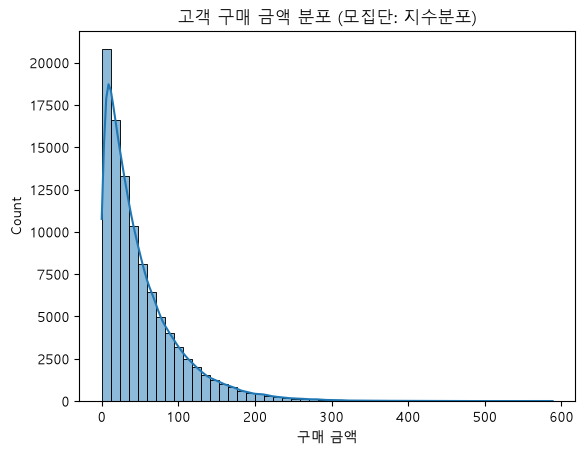

In [6]:
np.random.seed(2025)
population = np.random.exponential(scale=50, size=100000)  # 평균 50, 비대칭 분포

# 모집단 시각화
sns.histplot(population, bins=50, kde=True)
plt.title("고객 구매 금액 분포 (모집단: 지수분포)")
plt.xlabel("구매 금액")
plt.show()

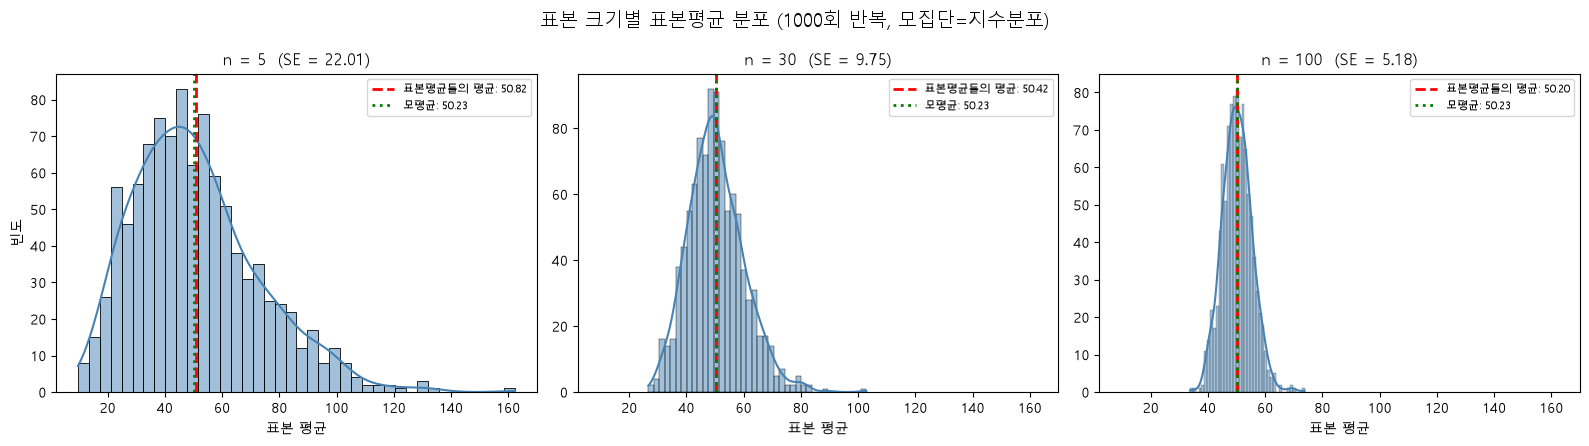

=== 모집단 (지수분포) ===
평균 50.233 | 중앙값 34.599 | 표준편차 50.321 | 왜도 2.003 | 첨도 5.988
평균 미만 고객 63.4% | 최댓값 588.4 (평균의 11.7배)

--- n=5 ---
평균 50.820 | SE 22.013 | 왜도 0.828 | 중앙95% 구간 17.62~100.06 (폭 82.44)
    이론SE 22.504 | 이론왜도 0.896 | 중앙값 47.646 (평균-중앙값 +3.174)
    모평균 ±10 이내 비율 36.4%

--- n=30 ---
평균 50.417 | SE 9.749 | 왜도 0.598 | 중앙95% 구간 33.22~71.42 (폭 38.20)
    이론SE 9.187 | 이론왜도 0.366 | 중앙값 49.662 (평균-중앙값 +0.755)
    모평균 ±10 이내 비율 71.1%

--- n=100 ---
평균 50.200 | SE 5.178 | 왜도 0.304 | 중앙95% 구간 40.45~60.50 (폭 20.05)
    이론SE 5.032 | 이론왜도 0.200 | 중앙값 50.095 (평균-중앙값 +0.104)
    모평균 ±10 이내 비율 95.0%



In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------- 모집단 ----------------
np.random.seed(2025)
population = np.random.exponential(scale=50, size=100000)

pop_mean = population.mean()
pop_std  = population.std(ddof=1)

# ---------------- 표본추출 ----------------
n_trials = 1000
sample_sizes = [5, 30, 100]

results = {}
for n in sample_sizes:
    np.random.seed(42)                      # n마다 동일 시드에서 시작
    results[n] = np.array([
        np.random.choice(population, size=n, replace=False).mean()
        for _ in range(n_trials)
    ])

# ---------------- 시각화 ----------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)

for ax, n in zip(axes, sample_sizes):
    means = results[n]
    sns.histplot(means, bins=40, kde=True, ax=ax, color='steelblue')

    ax.axvline(means.mean(), color='red', linestyle='--', linewidth=2,
               label=f'표본평균들의 평균: {means.mean():.2f}')
    ax.axvline(pop_mean, color='green', linestyle=':', linewidth=2,
               label=f'모평균: {pop_mean:.2f}')

    ax.set_title(f"n = {n}  (SE = {means.std(ddof=1):.2f})")
    ax.set_xlabel("표본 평균")
    ax.set_ylabel("빈도" if n == 5 else "")
    ax.legend(fontsize=8)

fig.suptitle(f"표본 크기별 표본평균 분포 ({n_trials}회 반복, 모집단=지수분포)", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------- 통계 출력 ----------------
print("=" * 62)
print("=== 모집단 (지수분포) ===")
print("=" * 62)
print(f"평균 {pop_mean:.3f} | 중앙값 {np.median(population):.3f} | "
      f"표준편차 {pop_std:.3f} | 왜도 {skew(population):.3f} | 첨도 {kurtosis(population):.3f}")
print(f"평균 미만 고객 {(population < pop_mean).mean()*100:.1f}% | "
      f"최댓값 {population.max():.1f} (평균의 {population.max()/pop_mean:.1f}배)")
print()

for n in sample_sizes:
    m = results[n]
    lo, hi = np.percentile(m, [2.5, 97.5])
    print(f"--- n={n} ---")
    print(f"평균 {m.mean():.3f} | SE {m.std(ddof=1):.3f} | 왜도 {skew(m):.3f} | "
          f"중앙95% 구간 {lo:.2f}~{hi:.2f} (폭 {hi-lo:.2f})")
    print(f"    이론SE {pop_std/np.sqrt(n):.3f} | "
          f"이론왜도 {skew(population)/np.sqrt(n):.3f} | "
          f"중앙값 {np.median(m):.3f} (평균-중앙값 {m.mean()-np.median(m):+.3f})")
    print(f"    모평균 ±10 이내 비율 {(np.abs(m-pop_mean)<10).mean()*100:.1f}%")
    print()

> 왜도 : 데이터 분포의 좌우 비대칭 정도를 나타냄
  - 왜도 = 0 좌우대칭
  - 왜도 > 0 = 그래프가 왼쪽으로 치우쳐짐
  - 왜도 < 0 = 그래프가 오른쪽으로 치우쳐짐

> 첨도 : 데이터 분포의 뾰족함 정도(높이)
  - 첨도 = 0 정규분포와 같음
  - 첨도 > 0 너무 뾰족함
  - 첨도 < 0 너무 완만함

> SE(StandarError 표준오차) : 표본평균이 모평균 주변에서 얼마나 흔들리는지 나타내는 값
  - **표본 평균**들의 **표준 편차**라는 의미로 이해하면 쉬움
  SE가 작다 = 추정이 정밀하다

### 표본 크기가 작을 때 (예: 5), 평균들의 분포는 어떤 모양인가요?
  - 오른쪽 꼬리가 길게 늘어진 비대칭 모양이다. 
  왜도의 수치가 0.8로 오른쪽 꼬리가 길게 늘어진 모습(모집단 분포의 왜도는 2.003으로 극심하게 왼쪽으로 치우쳐진 모습)
### 표본 크기가 커질수록 평균 분포의 모양은 어떤 변화를 보이나요?
  - 표본 크기가 커질수록 분포의 모양이 대칭이 되어간다(왜도로 확인 가능함)
  - 평균과 중앙값이 일치해짐
  - 그래프의 분포가 점점 좁아진다. 
  하지만 n=100일때도 왜도는 0이 되지 않는다. 그 이유는 n이 커지면 정규분포에 **수렴**하는거지 정규분포가 된다라는 말은 아니기 때문이다.
### 원래 모집단은 비대칭이었는데, 왜 평균들의 분포는 정규분포처럼 바뀌었을까요?
  - 평균을 내는 행위가 극단값을 희석시킨다라고 할 수 있다.
  표본 크기가 5일때 큰 값이 나올 확률은 높지만 표본 크기가 100이 된다면 전부 큰 값들이 나올 확률은 사실상 0에 가까움
  하지만 표본 평균이 50 근처가 될 확률은 굉장히 높음 -> 몇 명은 높고 몇 명은 낮은 조합이 나올 가능성은 무수히 많다.
  그래서 가운데는 두꺼워지고 양 끝은 얇아진다. 
### 이 실험을 통해 중심극한정리를 어떻게 이해하게 되었나요?
  - 모집단 분포를 몰라도 된다. 
  표본 크기에 따라 표본 평균의 분포는 정규분포에 수렴하기 때문에 신뢰구간, 가설 검정 등 정규분포 기반 추론을 사용할 수 있다.
  - 불확실성을 계산할 수 있다. 
  모평균 +-10 값에 대한 비율을 알 수가 있다. 표본크기가 100일때의 예시로 보자면 95%의 확률로 모평균 +-10값이 존재한다.
  - 정밀도의 수치를 알 수 있다.
  n을 5 -> 100으로 20배를 올렸음에도 SE는 4.2배만 줄어들었다. 이를 통해 정밀도를 올리기 위해 표본이 얼마나 더 필요한지 계산할 수 있다.
  - 중심극한정리는 표본 평균에 대한 이야기이지 모집단의 이야기가 아니다.
  하지만 평균값의 추정 정밀도는 중심극한정리로 알 수 있다.
### 표본 크기에 따라 **분포의 넓이(흩어짐)**는 어떻게 달라지나요?
  - n과 구간 폭은 줄어든다
  그래프에서 볼 수 있듯이 n이 5에서 100으로 갈수록 점점 좁아지는 것을 확인할 수 있다.
  위의 예시로 보면 
  n= 5 -> 100(20배), SE= 22.0 -> 5.2(4배감소)
  중앙 95% 구간 폭: 82.4 -> 20.05(4배감소) 같은 비율로 일치한다.

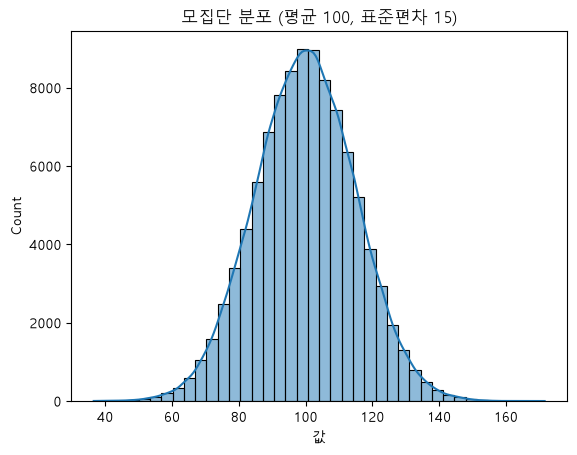

In [9]:
np.random.seed(2025)
population = np.random.normal(loc=100, scale=15, size=100000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 100, 표준편차 15)")
plt.xlabel("값")
plt.show()

모평균 99.9455 | 모표준편차 15.0333

  n  표본평균들의 평균  실측 SE  이론 SE      차이  오차율(%)
 10   100.0239 4.7204 4.7539 -0.0335 -0.7047
 30   100.0732 2.7207 2.7447 -0.0240 -0.8756
100   100.0479 1.5622 1.5033  0.0589  3.9169
500    99.9651 0.6504 0.6723 -0.0220 -3.2655


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


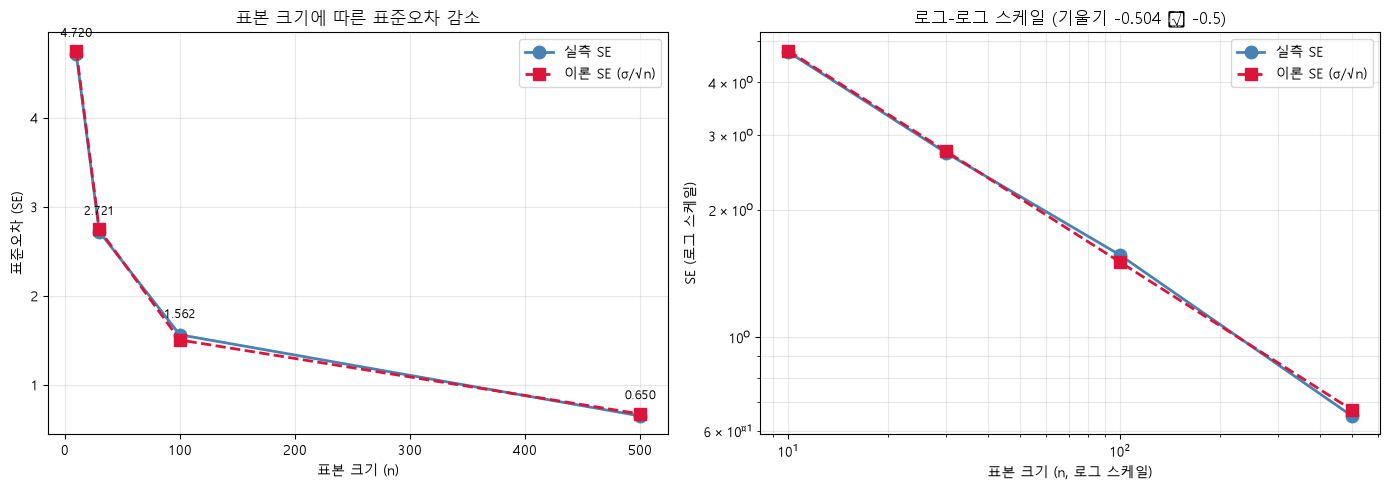

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------- 모집단 ----------------
np.random.seed(2025)
population = np.random.normal(loc=100, scale=15, size=100000)

pop_mean = population.mean()
pop_std  = population.std(ddof=1)

# ---------------- 표본추출 ----------------
n_trials = 1000
sample_sizes = [10, 30, 100, 500]

results = {}
for n in sample_sizes:
    np.random.seed(42)
    results[n] = np.array([
        np.random.choice(population, size=n, replace=False).mean()
        for _ in range(n_trials)
    ])

# ---------------- 비교표 ----------------
df_se = pd.DataFrame({
    'n': sample_sizes,
    '표본평균들의 평균': [results[n].mean()          for n in sample_sizes],
    '실측 SE':          [results[n].std(ddof=1)     for n in sample_sizes],
    '이론 SE':          [pop_std / np.sqrt(n)       for n in sample_sizes],
})
df_se['차이']     = df_se['실측 SE'] - df_se['이론 SE']
df_se['오차율(%)'] = df_se['차이'] / df_se['이론 SE'] * 100

print(f"모평균 {pop_mean:.4f} | 모표준편차 {pop_std:.4f}\n")
print(df_se.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ---------------- 꺾은선 그래프 ----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) 일반 스케일
ax = axes[0]
ax.plot(df_se['n'], df_se['실측 SE'], 'o-',  lw=2, ms=9, color='steelblue', label='실측 SE')
ax.plot(df_se['n'], df_se['이론 SE'], 's--', lw=2, ms=8, color='crimson',   label='이론 SE (σ/√n)')
for _, r in df_se.iterrows():
    ax.annotate(f"{r['실측 SE']:.3f}", (r['n'], r['실측 SE']),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9)
ax.set_xlabel("표본 크기 (n)")
ax.set_ylabel("표준오차 (SE)")
ax.set_title("표본 크기에 따른 표준오차 감소")
ax.legend()
ax.grid(alpha=0.3)

# (우) 로그-로그 스케일
ax = axes[1]
ax.plot(df_se['n'], df_se['실측 SE'], 'o-',  lw=2, ms=9, color='steelblue', label='실측 SE')
ax.plot(df_se['n'], df_se['이론 SE'], 's--', lw=2, ms=8, color='crimson',   label='이론 SE (σ/√n)')
ax.set_xscale('log')
ax.set_yscale('log')
slope = np.polyfit(np.log(df_se['n']), np.log(df_se['실측 SE']), 1)[0]
ax.set_xlabel("표본 크기 (n, 로그 스케일)")
ax.set_ylabel("SE (로그 스케일)")
ax.set_title(f"로그-로그 스케일 (기울기 {slope:.3f} ≈ -0.5)")
ax.legend()
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

### 표본 크기가 작을수록, 표본 평균의 분포는 어떤 모양인가요? 넓게 퍼져 있나요?
  - 표본 크기가 작을수록 넓게 퍼져있다. 하지만 모집단의 분포를 보면 이미 정규분포이다. (SE=4.72)
  따라서 표본 평균의 분포 역시 정규분포로 나온다.
### 표본 크기가 커질수록, 평균 분포는 어떻게 변하나요?
  - SE가 4.72에서 0.65로 급격하게 감소하였다
  즉 표본 크기가 커질수록 분포는 감소한다.
### 실험값과 이론값(공식 계산값)은 얼마나 비슷한가요?
  - 오차율이 전부 4% 이내에 있다. 남은 차이는 공식이 틀려서가 아니라 **몬테카를로 오차**이다.
  1000번 계산한것도 유한한 실험이라 거기서 계산한 SE도 자신만의 오차를 가짐, n을 10000번 진행하면 오차율이 1%아래로 다시 내려감
  - 로그-로그 기울기를 보면 더 정확하게 알 수 있다.
  개별 점의 오차와 무관하게 **관계 형태 자체를 검증**
  이론적으로 공식에 대입해보면 -0.5의 기울기가 나와야 하고 실제 실측결과에서 -0.7%가 나왔으니 법칙이 성립했다고 볼 수 있다.
### 왜 표본 크기가 커질수록 표준오차는 작아질까요?
  - SE = √(σ²/n) = σ/√n
  합은 √n으로 커지는데 평균을 내기 위해 나누는건 n이다.
  n=10일때의 표준편차 합: 47.34 / n=100일때의 표준편차 합: 150.62 -> 이걸 각각 10과 100으로 나누면 4.73과 1.50의 표준오차값이 나온다
  즉 n을 10배 키웠는데 
  - 오차들이 서로 상쇄된다.
  표본들의 개별 편차(각 값 - 모평균)가 얼마나 서로 지워지는지 측정한 것으로 알 수 있다.
  n=100에서 90%가 상쇄된다. 우연히 뽑기 때문에 우연히 한쪽으로 치우칠 수 있고 그 불균형이 표본평균을 참값에서 밀어낸다.
  즉 n이 커질수록 **우연히 한쪽으로 몰릴 확률**이 낮아지고 그래서 오차가 작아진다.
  - 극단값이 희석된다.
  표본이 많아지면 극단값이 들어와도 표본 평균이 밀리는 수치가 매우 줄어든다. 

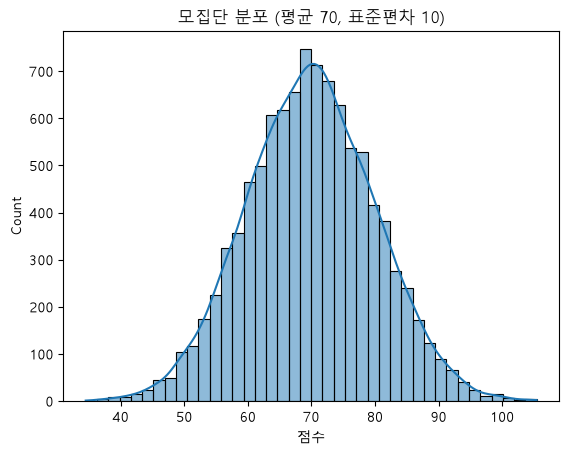

In [11]:
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 70, 표준편차 10)")
plt.xlabel("점수")
plt.show()

표본크기 n        = 30
표본평균 x̄        = 70.2810
표본표준편차 s     = 10.1892
모표준편차 σ(가정) = 15.0333
SE (z, σ/√n)      = 2.7447
SE (t, s/√n)      = 1.8603

신뢰수준  z임계값    z하한    z상한     z폭  t임계값    t하한    t상한     t폭
 90% 1.645 65.766 74.796  9.029 1.699 67.120 73.442  6.322
 95% 1.960 64.901 75.660 10.759 2.045 66.476 74.086  7.609
 99% 2.576 63.211 77.351 14.140 2.756 65.153 75.409 10.255


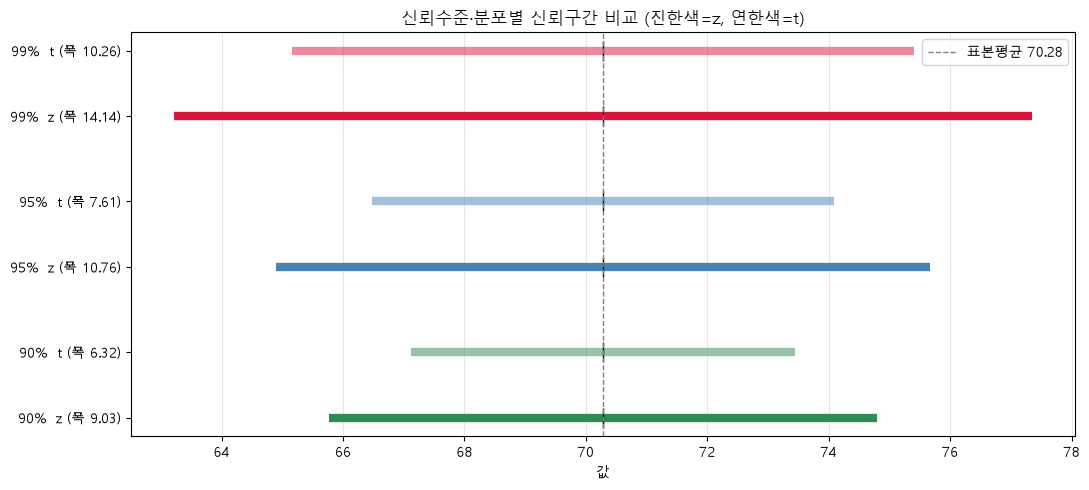

In [13]:
from scipy import stats
# ---------------- 표본 30명 추출 ----------------
np.random.seed(42)
sample = np.random.choice(population, size=30, replace=False)

n    = len(sample)
xbar = sample.mean()
s    = sample.std(ddof=1)

se_z = pop_std / np.sqrt(n)    # z용 표준오차: 모표준편차 σ 사용
se_t = s       / np.sqrt(n)    # t용 표준오차: 표본표준편차 s 사용

print(f"표본크기 n        = {n}")
print(f"표본평균 x̄        = {xbar:.4f}")
print(f"표본표준편차 s     = {s:.4f}")
print(f"모표준편차 σ(가정) = {pop_std:.4f}")
print(f"SE (z, σ/√n)      = {se_z:.4f}")
print(f"SE (t, s/√n)      = {se_t:.4f}\n")

# ---------------- 신뢰수준별 z / t 신뢰구간 ----------------
rows = []
for conf in [0.90, 0.95, 0.99]:
    alpha = 1 - conf
    z = stats.norm.ppf(1 - alpha/2)
    t = stats.t.ppf(1 - alpha/2, df=n-1)

    z_lo, z_hi = xbar - z*se_z, xbar + z*se_z
    t_lo, t_hi = xbar - t*se_t, xbar + t*se_t

    rows.append({
        '신뢰수준': f"{int(conf*100)}%",
        'z임계값': z, 'z하한': z_lo, 'z상한': z_hi, 'z폭': z_hi - z_lo,
        't임계값': t, 't하한': t_lo, 't상한': t_hi, 't폭': t_hi - t_lo,
    })

df_ci = pd.DataFrame(rows)
print(df_ci.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ---------------- 신뢰구간 폭 시각화 ----------------
fig, ax = plt.subplots(figsize=(11, 5))
colors = {'90%': 'seagreen', '95%': 'steelblue', '99%': 'crimson'}
y = 0
yticks, ylabels = [], []

for _, r in df_ci.iterrows():
    lv = r['신뢰수준']
    # z 구간
    ax.plot([r['z하한'], r['z상한']], [y, y], color=colors[lv], lw=6, solid_capstyle='butt')
    ax.plot(xbar, y, 'k|', ms=14)
    yticks.append(y); ylabels.append(f"{lv}  z (폭 {r['z폭']:.2f})")
    y += 1
    # t 구간
    ax.plot([r['t하한'], r['t상한']], [y, y], color=colors[lv], lw=6, alpha=0.5, solid_capstyle='butt')
    ax.plot(xbar, y, 'k|', ms=14)
    yticks.append(y); ylabels.append(f"{lv}  t (폭 {r['t폭']:.2f})")
    y += 1.3

ax.axvline(xbar, color='gray', linestyle='--', lw=1, label=f'표본평균 {xbar:.2f}')
ax.set_yticks(yticks); ax.set_yticklabels(ylabels)
ax.set_xlabel("값")
ax.set_title("신뢰수준·분포별 신뢰구간 비교 (진한색=z, 연한색=t)")
ax.legend(loc='upper right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### z-분포와 t-분포를 사용한 신뢰구간은 얼마나 차이가 있나요?
  - 같은 신뢰 수준에서 t-분포를 사용한 신뢰구간이 조금 더 넓다.
  그 이유는 z-분포는 모표준편차를 알고 있다고 가정하고 t-분포는 모표준편차를 모르고 s를 사용한 표준오차를 사용해서 추정하는 상황
  이때 s는 표본마다 흔들리는 추정값이라 불안성을 감안해 구간을 조금 더 넓게 잡는다.
### 신뢰수준이 높아질수록 신뢰구간의 폭은 어떻게 변하나요? 왜 그럴까요?
  - 신뢰 수준이 높아질수록 신뢰구간의 폭은 더 커진다. 90% -> 99%로 갈때 1.57배가 더 커진다
  - 90% 신뢰: 놓칠 확률 10%감수 -> 좁게 쳐도 된다
  - 99% 신뢰: 놓칠 확률을 1%까지 낮춤 -> 더 크게 쳐서 참 값을 더 확실하게 잡는다.
### 신뢰구간이 넓다는 건 좋은 걸까요? 나쁜 걸까요?
  - 신뢰구간이 넓다 = 진짜 값이 특정 구간 사이에 있다 / 신뢰구간이 좁다 = 특정 값을 추정할 수 있다
  - 무엇을 원하느냐에 따라 다름
  - 10번중에 9번을 맞추겠다(90%) - 좁은 구간이어도 가능 / 100번을 던져 99번을 맞추겠다(99%) - 구간을 넓게 쳐야 그만큼 확실하게 잡을 수 있음
  - 다만 데이터가 적어서 넓어진 경우는 위험신호이므로 정밀도의 한계인지 아니면 표본이 적어서인지 판단하는것이 중요하다.
### 이 데이터가 실제 고객 만족도라면, 신뢰구간 정보를 마케팅 전략에 어떻게 활용할 수 있을까요?
  - 만족도 100점을 기준으로 평균이 70점이라면 신뢰구간을 바탕으로 66.7 ~ 73.9점으로 보고한다
  - 만족도 65점 이상이 목표였고 실제 하한이 66.7이기 때문에 95% 확신으로 목표를 달성하였다 라고 할 수 있다
  - 새로운 캠페인을 실시한 후 재조사를 했을때 구간이 이전보다 높게 나왔다면 마케팅이 효과가 있었다 라고 할 수 있다
  반면에 다시 비슷한 구간(겹치는 구간)이 나왔다면 효과가 있었다라고 할 수 없다.

표본크기 n     = 40
표본평균 x̄     = 7.3996
표본표준편차 s = 1.0961
표준오차 SE    = 0.1733
t 임계값(df=39) = 2.0227
오차한계 ±     = 0.3505
95% 신뢰구간   = [7.0491, 7.7502]  (폭 0.7011)


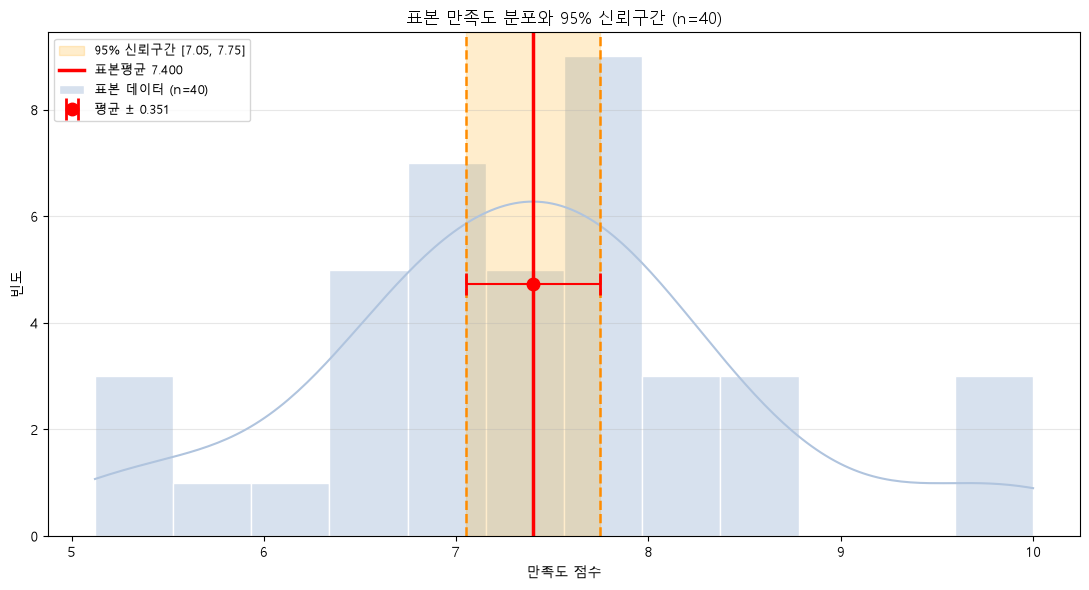

In [14]:
from scipy import stats

warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------- 모집단 ----------------
np.random.seed(2025)
population = np.random.normal(loc=7.2, scale=1.0, size=10000)
population = np.clip(population, 1, 10)

# ---------------- 표본 40명 추출 ----------------
np.random.seed(42)
sample = np.random.choice(population, size=40, replace=False)

n    = len(sample)
xbar = sample.mean()
s    = sample.std(ddof=1)       # 표본표준편차
se   = s / np.sqrt(n)           # 표준오차

# ---------------- t-분포 95% 신뢰구간 ----------------
conf  = 0.95
t_crit = stats.t.ppf(1 - (1-conf)/2, df=n-1)
margin = t_crit * se
ci_lo, ci_hi = xbar - margin, xbar + margin

print(f"표본크기 n     = {n}")
print(f"표본평균 x̄     = {xbar:.4f}")
print(f"표본표준편차 s = {s:.4f}")
print(f"표준오차 SE    = {se:.4f}")
print(f"t 임계값(df={n-1}) = {t_crit:.4f}")
print(f"오차한계 ±     = {margin:.4f}")
print(f"95% 신뢰구간   = [{ci_lo:.4f}, {ci_hi:.4f}]  (폭 {ci_hi-ci_lo:.4f})")

# ---------------- 시각화 ----------------
fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(sample, bins=12, kde=True, color='lightsteelblue',
             edgecolor='white', ax=ax, label='표본 데이터 (n=40)')

# 신뢰구간 음영
ax.axvspan(ci_lo, ci_hi, color='orange', alpha=0.2,
           label=f'95% 신뢰구간 [{ci_lo:.2f}, {ci_hi:.2f}]')

# 평균선
ax.axvline(xbar, color='red', linestyle='-', linewidth=2.5,
           label=f'표본평균 {xbar:.3f}')
# 신뢰구간 경계선
ax.axvline(ci_lo, color='darkorange', linestyle='--', linewidth=1.8)
ax.axvline(ci_hi, color='darkorange', linestyle='--', linewidth=1.8)

# 오차막대 (평균 ± 오차한계)
ax.errorbar(xbar, ax.get_ylim()[1]*0.5, xerr=margin, fmt='o',
            color='red', capsize=8, capthick=2, markersize=9,
            label=f'평균 ± {margin:.3f}')

ax.set_xlabel("만족도 점수")
ax.set_ylabel("빈도")
ax.set_title(f"표본 만족도 분포와 95% 신뢰구간 (n={n})")
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 신뢰구간은 몇 점에서 몇 점 사이인가요?
  - 7.05점에서 7.75점 사이
### 이 구간은 전체 모집단 평균을 포함하고 있나요?
  - 모평균은 7.19이고 신뢰구간 사이에 포함되어 있다.
  이 구간이 참값을 포함할 확률이 95%"는 틀린 해석이다. 참값 7.19는 고정된 상수라 이미 들어있거나 아니거나 둘 중 하나임(이번엔 들어있음). 
  정확히는 **"이런 식으로 표본 뽑아 구간 만들기를 100번 반복하면 95번쯤은 참값을 포함한다"**라는 뜻이다.
### 이 결과를 바탕으로 고객 만족도가 충분히 높다고 말할 수 있을까요?
  - 이 결과는 통계만으로는 답할 수 없다, 신뢰구간은 판단 재료를 줄 뿐 판단 자체는 목표선과 비교해야함
  기준선을 정하고 하한과 비교해봐야함
### 만약 신뢰구간이 너무 넓게 나왔다면, 그 이유는 무엇이고 어떻게 개선할 수 있을까요?
  - 표본이 작다 - 가장 흔한 원인
  - 데이터가 흩어져 있다
  - 신뢰 수준이 높다(99%)